# Part A – Legal & Courtesy Amount Detection
**ICS472 – Natural Language Processing**  
**Team:** Mohammed Al Sheqaih · Abdulrhman Ammar

**Goal:** Train a YOLOv8 object detector to locate two regions in each check image:
- **Class 0 – Legal amount** (handwritten Arabic text region)
- **Class 1 – Courtesy amount** (digit region)

**Evaluation metrics:** Accuracy @ IoU ≥ {0.50, 0.75, 0.90} and Mean IoU

**Output:** Bounding-box predictions on the test set + saved crops for Parts B and C

## 1. Imports & Setup

In [ ]:
%matplotlib inline

import sys, os, shutil, json, random
sys.path.insert(0, os.path.abspath('.'))

import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import torch
from ultralytics import YOLO

from utils import (
    TRAIN_IMAGES, TEST_IMAGES, TRAIN_BBOX, TEST_BBOX, ARTIFACTS,
    parse_bbox, load_image, crop_region, yolo_to_xyxy, detection_metrics
)

# Device 
if torch.cuda.is_available():
    DEVICE = 'cuda'
    print('CUDA is available. Using GPU.')
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['figure.dpi'] = 120

YOLO_DIR  = ARTIFACTS / 'yolo_dataset'
CROPS_DIR = ARTIFACTS / 'crops'
RUNS_DIR  = ARTIFACTS / 'yolo_runs'


CUDA is available. Using GPU.
Device: cuda


## 2. Prepare YOLO Dataset

YOLOv8 expects this layout:
```
yolo_dataset/
├── images/
│   ├── train/   (80 % of labelled images)
│   ├── val/     (20 % of labelled images)
│   └── test/
└── labels/
    ├── train/
    ├── val/
    └── test/
```
We use **symlinks** for images (avoids duplicating ~2 GB of TIFFs) and copy the small label `.txt` files.

`ac00048` is excluded — it has no bounding-box annotation.

In [ ]:
MISSING = {'ac00048'}  # no bbox label

def build_yolo_dirs():
    if YOLO_DIR.exists():
        shutil.rmtree(YOLO_DIR)
    for split in ('train', 'val', 'test'):
        (YOLO_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
        (YOLO_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

def copy_as_rgb(src, dst):
    """Open any TIFF (including grayscale) and save as 3-channel RGB."""
    Image.open(src).convert('RGB').save(dst)

def populate_split(stems, split, img_src, lbl_src):
    for stem in tqdm(stems, desc=f'  {split}', leave=False):
        img_file = img_src / f'{stem}.tif'
        lbl_file = lbl_src / f'{stem}.txt'
        if img_file.exists():
            copy_as_rgb(img_file, YOLO_DIR / 'images' / split / f'{stem}.tif')
        if lbl_file.exists():
            shutil.copy2(lbl_file, YOLO_DIR / 'labels' / split / f'{stem}.txt')

# Collect labelled train stems
all_train_stems = sorted(
    p.stem for p in TRAIN_BBOX.glob('*.txt')
    if p.stem not in MISSING
)
random.shuffle(all_train_stems)
split_idx   = int(0.8 * len(all_train_stems))
train_stems = all_train_stems[:split_idx]
val_stems   = all_train_stems[split_idx:]
test_stems  = [p.stem for p in sorted(TEST_IMAGES.glob('*.tif'))]

print(f'Train: {len(train_stems)} | Val: {len(val_stems)} | Test: {len(test_stems)}')

# Build directory structure & copy as RGB
build_yolo_dirs()
populate_split(train_stems, 'train', TRAIN_IMAGES, TRAIN_BBOX)
populate_split(val_stems,   'val',   TRAIN_IMAGES, TRAIN_BBOX)
populate_split(test_stems,  'test',  TEST_IMAGES,  TEST_BBOX)

print('Dataset directories ready (all images converted to RGB).')


Train: 1439 | Val: 360 | Test: 600


Dataset directories ready (all images converted to RGB).


In [ ]:
#  Write data.yaml 
data_yaml = {
    'path':  str(YOLO_DIR.resolve()),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc':    2,
    'names': {0: 'legal', 1: 'courtesy'},
}
yaml_path = YOLO_DIR / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f'data.yaml saved to: {yaml_path}')
print(open(yaml_path).read())

data.yaml saved to: C:\Users\Admin\Desktop\NLP_Project\arabic-bank-check-processing\codebase\artifacts\yolo_dataset\data.yaml
path: C:\Users\Admin\Desktop\NLP_Project\arabic-bank-check-processing\codebase\artifacts\yolo_dataset
train: images/train
val: images/val
test: images/test
nc: 2
names:
  0: legal
  1: courtesy



## 3. Train YOLOv8

We use **YOLOv8s** (small variant) pre-trained on COCO with the following improvements over a vanilla fine-tune:

**Loss improvements**
- `box=7.5` — explicit **CIoU** box regression weight; penalises centre-point distance and aspect-ratio mismatch, critical for long thin legal-text boxes
- `dfl=1.5` — **Distribution Focal Loss** weight; models a probability distribution over box edges instead of a single point, helping with fuzzy handwritten boundaries

**Scale & resolution robustness**
- `scale=0.5` — random ±50 % scale jitter per batch (multi-scale training)
- `mosaic=1.0` — combine 4 images into one mosaic; forces detection of smaller objects within a standard frame
- `imgsz=1024` — higher pixel density helps the CNN distinguish fine Arabic character flourishes *(set to 640 to trade accuracy for speed)*

**Handwriting-specific augmentation**
- `degrees=15.0` — random ±15° rotation to handle tilted check scans
- `shear=10.0` — random shear for perspective-like distortion
- `perspective=0.0005` — GPU-accelerated perspective warp simulating scanner angle variation

**Efficiency**
- `rect=True` — rectangular training avoids square-padding of rectangular checks, reducing ~30 % wasted pixel computation
- `patience=20` — early stopping once validation mAP plateaus

> **Runtime:** ~60–120 min on RTX 5060 at imgsz=1024 (use imgsz=640 + batch=16 if time is limited).

In [ ]:
from tqdm.notebook import tqdm as tqdm_nb

model = YOLO('yolov8s.pt')  # downloads pretrained weights on first run

EPOCHS = 150
pbar  = tqdm_nb(total=EPOCHS, desc='Training', unit='epoch', dynamic_ncols=True)
_log  = []  # accumulate per-epoch metrics for the plot

def on_train_epoch_end(trainer):
    ep      = trainer.epoch + 1
    metrics = trainer.metrics
    loss    = trainer.loss.item() if hasattr(trainer.loss, 'item') else float(trainer.loss)
    map50   = metrics.get('metrics/mAP50(B)', float('nan'))
    map5095 = metrics.get('metrics/mAP50-95(B)', float('nan'))
    _log.append({'epoch': ep, 'loss': loss, 'mAP50': map50, 'mAP50-95': map5095})
    pbar.set_postfix(loss=f'{loss:.4f}', mAP50=f'{map50:.4f}', mAP50_95=f'{map5095:.4f}')
    pbar.update(1)
    tqdm_nb.write(
        f'Epoch {ep:>3}/{EPOCHS} | loss={loss:.4f} | mAP50={map50:.4f} | mAP50-95={map5095:.4f}'
    )

def on_train_end(trainer):
    pbar.close()

model.add_callback('on_train_epoch_end', on_train_epoch_end)
model.add_callback('on_train_end',       on_train_end)

train_results = model.train(
    data    = str(yaml_path),
    epochs  = EPOCHS,
    imgsz   = 1024,        # from 640; use 640 to trade accuracy for speed
    batch   = 8,           # reduce to 4 if OOM at imgsz=1024
    device  = DEVICE,
    patience= 20,
    seed    = SEED,
    project = str(RUNS_DIR),
    name    = 'yolov8s_checks',
    exist_ok= True,
    verbose = False,
    workers = 0,           # Windows fix: disable DataLoader multiprocessing

    # Loss weights (CIoU + DFL)
    box     = 7.5,         # CIoU box regression loss weight
    dfl     = 1.5,         # Distribution Focal Loss weight

    #  Scale & resolution robustness 
    scale   = 0.5,         # random ±50% scale jitter (multi-scale training)
    mosaic  = 1.0,         # mosaic augmentation — 4 images per tile

    #  Handwriting-specific augmentation 
    degrees = 15.0,        # random rotation ±15°
    shear   = 10.0,        # random shear ±10°
    perspective = 0.0005,  # perspective warp

    # Efficiency 
    rect    = True,        # rectangular training  avoids padding checks to squares
)

BEST_WEIGHTS = RUNS_DIR / 'yolov8s_checks' / 'weights' / 'best.pt'
print(f'\nBest weights: {BEST_WEIGHTS}')

#  Training curve 
if _log:
    epochs_arr = [r['epoch']    for r in _log]
    losses     = [r['loss']     for r in _log]
    map50s     = [r['mAP50']    for r in _log]
    map5095s   = [r['mAP50-95'] for r in _log]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(epochs_arr, losses, color='steelblue')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss'); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_arr, map50s,   label='mAP@0.50',     color='darkorange')
    ax2.plot(epochs_arr, map5095s, label='mAP@0.50:0.95', color='green')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('mAP')
    ax2.set_title('Validation mAP'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(ARTIFACTS / 'partA_training_curves.png', bbox_inches='tight')
    plt.show()


Training:   0%|          | 0/150 [00:00<?, ?epoch/s]

New https://pypi.org/project/ultralytics/8.4.48 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.10.19 torch-2.12.0.dev20260219+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Admin\Desktop\NLP_Project\arabic-bank-check-processing\codebase\artifacts\yolo_dataset\data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=

<Figure size 1560x480 with 2 Axes>

## 4. Validation Metrics (Built-in YOLO Report)

In [6]:
BEST_WEIGHTS = RUNS_DIR / 'yolov8s_checks' / 'weights' / 'best.pt'

best_model = YOLO(str(BEST_WEIGHTS))
val_results = best_model.val(
    data   = str(yaml_path),
    split  = 'val',
    device = DEVICE,
    verbose= True,
)
print('mAP50  :', round(val_results.box.map50, 4))
print('mAP50-95:', round(val_results.box.map,  4))


Ultralytics 8.4.14  Python-3.10.19 torch-2.12.0.dev20260219+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8151MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 23.56.1 MB/s, size: 123.5 KB)
val: Scanning C:\Users\Admin\Desktop\NLP_Project\arabic-bank-check-processing\codebase\artifacts\yolo_dataset\labels\val... 360 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 360/360 875.9it/s 0.4s<0.0s
val: New cache created: C:\Users\Admin\Desktop\NLP_Project\arabic-bank-check-processing\codebase\artifacts\yolo_dataset\labels\val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 6.9it/s 3.3s0.1s
                   all        360        720      0.864      0.885      0.916      0.548
                 legal        360        360      0.882      0.964      0.976      0.613
              courtesy        360        360      0.846      0.806      0.857 

## 5. Custom Evaluation on Test Set

We compute the project-specific metrics on the **test set**:
- Accuracy @ IoU ≥ 0.50 / 0.75 / 0.90
- Mean IoU

Both classes (legal + courtesy) are evaluated together as the assignment specifies.

In [ ]:
BEST_WEIGHTS = RUNS_DIR / 'yolov8s_checks' / 'weights' / 'best.pt'
best_model   = YOLO(str(BEST_WEIGHTS))

test_imgs = sorted(TEST_IMAGES.glob('*.tif'))

predictions    = []
ground_truths  = []
pred_boxes_raw = []  # store raw xyxy predictions for crop saving

for img_path in tqdm(test_imgs, desc='Evaluating test set'):
    img      = Image.open(img_path).convert('RGB')  #  3-channel for YOLO
    W, H     = img.size

    #  Model prediction 
    result   = best_model(img, verbose=False)[0]   # pass PIL image, not path
    pred     = {'courtesy': None, 'legal': None}
    pred_raw = {}
    for box in result.boxes:
        cls_id = int(box.cls)
        xyxy   = [round(v, 1) for v in box.xyxy[0].tolist()]
        key    = 'courtesy' if cls_id == 1 else 'legal'
        # keep the highest-confidence box per class
        if pred[key] is None:
            pred[key]     = xyxy
            pred_raw[key] = xyxy
    predictions.append(pred)
    pred_boxes_raw.append({'stem': img_path.stem, 'boxes': pred_raw, 'size': (W, H)})

    #  Ground truth 
    gt      = {'courtesy': None, 'legal': None}
    gt_path = TEST_BBOX / (img_path.stem + '.txt')
    if gt_path.exists():
        for cls, cx, cy, bw, bh in parse_bbox(gt_path):
            key     = 'courtesy' if cls == 1 else 'legal'
            gt[key] = yolo_to_xyxy(cx, cy, bw, bh, W, H)
    ground_truths.append(gt)

#  Compute metrics 
metrics = detection_metrics(predictions, ground_truths, thresholds=(0.5, 0.75, 0.9))
print('\n── Test Set Detection Metrics ──')
for k, v in metrics.items():
    print(f'  {k}: {v}')


Evaluating test set: 100%|██████████| 600/600 [00:10<00:00, 56.98it/s]


── Test Set Detection Metrics ──
  acc@0.5: 76.08
  acc@0.75: 30.75
  acc@0.9: 3.75
  mean_iou: 63.35


In [8]:
# ── Per-class IoU breakdown ────────────────────────────────────────────────
ca_ious, la_ious = [], []

from utils import iou
for pred, gt in zip(predictions, ground_truths):
    for key, lst in (('courtesy', ca_ious), ('legal', la_ious)):
        if pred[key] and gt[key]:
            lst.append(iou(pred[key], gt[key]))
        else:
            lst.append(0.0)

print(f'Courtesy — Mean IoU: {np.mean(ca_ious)*100:.2f}%')
print(f'Legal    — Mean IoU: {np.mean(la_ious)*100:.2f}%')

# ── Save metrics to disk ──────────────────────────────────────────────────
metrics_out = {
    **metrics,
    'courtesy_mean_iou': round(float(np.mean(ca_ious)) * 100, 2),
    'legal_mean_iou':    round(float(np.mean(la_ious)) * 100, 2),
}
with open(ARTIFACTS / 'partA_metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)
print('\nMetrics saved to artifacts/partA_metrics.json')

Courtesy — Mean IoU: 52.47%
Legal    — Mean IoU: 74.23%

Metrics saved to artifacts/partA_metrics.json


## 6. Visualise Predictions vs Ground Truth

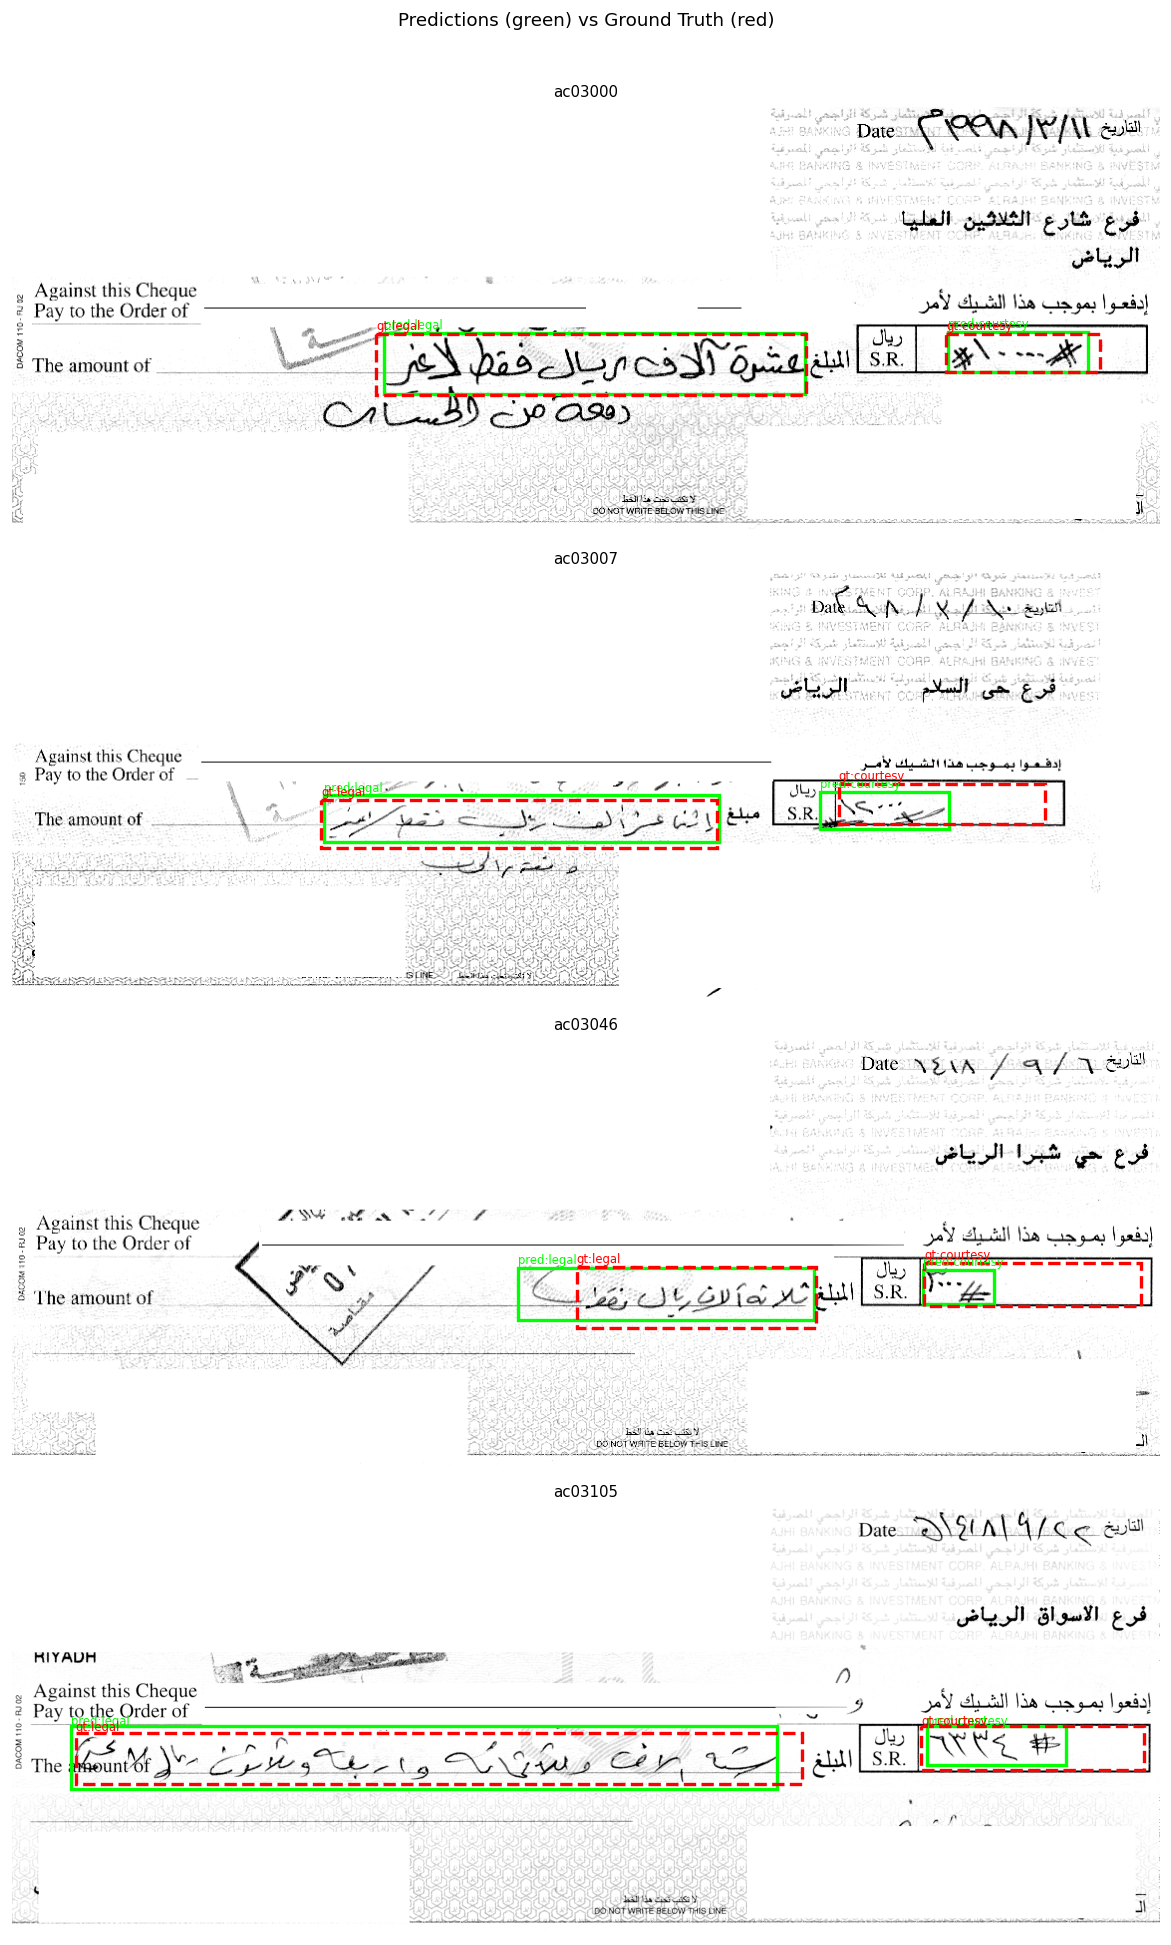

In [14]:
def draw_boxes(ax, img, pred, gt, title=''):
    ax.imshow(img, cmap='gray')
    styles = [
        ('pred',  pred, 'lime',  '-'),
        ('gt',    gt,   'red',   '--'),
    ]
    for label_prefix, boxes, color, ls in styles:
        for key, box in boxes.items():
            if box is None:
                continue
            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color, facecolor='none', linestyle=ls
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, f'{label_prefix}:{key}', color=color, fontsize=7)
    ax.axis('off')
    ax.set_title(title, fontsize=9)

fig, axes = plt.subplots(4, 1, figsize=(13, 16))
sample_idxs = [0, 5, 20, 50]
for ax, idx in zip(axes, sample_idxs):
    img = Image.open(test_imgs[idx])
    draw_boxes(ax, img, predictions[idx], ground_truths[idx],
               title=test_imgs[idx].stem)
plt.suptitle('Predictions (green) vs Ground Truth (red)', y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(ARTIFACTS / 'partA_predictions.png', bbox_inches='tight')
plt.show()


## 7. Save Crops for Parts B and C

- **Train crops** — cropped using **ground-truth** bboxes (clean signal for training the recognisers)
- **Test crops**  — cropped using **model predictions** (simulates the real end-to-end pipeline)

Files are named `Cac#####.tif` (courtesy) and `Lac#####.tif` (legal) to match the annotation files.

In [10]:
for split in ('train', 'test'):
    for region in ('courtesy', 'legal'):
        (CROPS_DIR / split / region).mkdir(parents=True, exist_ok=True)

def save_crop(img_path, cx, cy, bw, bh, out_path):
    img  = load_image(img_path)
    crop = crop_region(img, cx, cy, bw, bh)
    crop.save(out_path)

# ── Train crops (ground truth bboxes) ─────────────────────────────────────
train_img_paths = sorted(TRAIN_IMAGES.glob('*.tif'))
skipped = 0
for img_path in tqdm(train_img_paths, desc='Saving train crops'):
    if img_path.stem in MISSING:
        skipped += 1
        continue
    lbl_path = TRAIN_BBOX / (img_path.stem + '.txt')
    if not lbl_path.exists():
        skipped += 1
        continue
    for cls, cx, cy, bw, bh in parse_bbox(lbl_path):
        region  = 'courtesy' if cls == 1 else 'legal'
        prefix  = 'C' if cls == 1 else 'L'
        out     = CROPS_DIR / 'train' / region / f'{prefix}{img_path.stem}.tif'
        save_crop(img_path, cx, cy, bw, bh, out)
print(f'Train crops done. Skipped: {skipped}')

Saving train crops: 100%|██████████| 1800/1800 [00:30<00:00, 59.59it/s]

Train crops done. Skipped: 1


In [13]:
# ── Test crops (model predictions) ────────────────────────────────────────
missing_preds = 0
for entry in tqdm(pred_boxes_raw, desc='Saving test crops'):
    stem     = entry['stem']
    img_path = TEST_IMAGES / f'{stem}.tif'
    img      = load_image(img_path)
    W, H     = img.size

    for key, (cls_id, prefix) in {
        'courtesy': (1, 'C'),
        'legal':    (0, 'L'),
    }.items():
        box = entry['boxes'].get(key)
        if box is None:
            # fall back to ground truth if model missed the box
            gt_path = TEST_BBOX / f'{stem}.txt'
            if gt_path.exists():
                for c, cx, cy, bw, bh in parse_bbox(gt_path):
                    if c == cls_id:
                        box = yolo_to_xyxy(cx, cy, bw, bh, W, H)
                        break
            if box is None:
                missing_preds += 1
                continue
        x1, y1, x2, y2 = [int(v) for v in box]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        crop    = img.crop((x1, y1, x2, y2))
        out     = CROPS_DIR / 'test' / key / f'{prefix}{stem}.tif'
        crop.save(out)

print(f'Test crops done. Missing predictions (fell back to GT): {missing_preds}')

Saving test crops: 100%|██████████| 600/600 [00:02<00:00, 258.10it/s]

Test crops done. Missing predictions (fell back to GT): 0


## 8. Summary

In [11]:
train_ca_crops = list((CROPS_DIR / 'train' / 'courtesy').glob('*.tif'))
train_la_crops = list((CROPS_DIR / 'train' / 'legal').glob('*.tif'))
test_ca_crops  = list((CROPS_DIR / 'test'  / 'courtesy').glob('*.tif'))
test_la_crops  = list((CROPS_DIR / 'test'  / 'legal').glob('*.tif'))

print('── Part A Complete ──')
print(f"  Acc @ IoU≥0.50 : {metrics['acc@0.5']}%")
print(f"  Acc @ IoU≥0.75 : {metrics['acc@0.75']}%")
print(f"  Acc @ IoU≥0.90 : {metrics['acc@0.9']}%")
print(f"  Mean IoU       : {metrics['mean_iou']}%")
print()
print(f'  Crops saved:')
print(f'    Train courtesy : {len(train_ca_crops)}')
print(f'    Train legal    : {len(train_la_crops)}')
print(f'    Test  courtesy : {len(test_ca_crops)}')
print(f'    Test  legal    : {len(test_la_crops)}')
print()
print('  → Run 02_Part_B_Courtesy.ipynb next')

── Part A Complete ──
  Acc @ IoU≥0.50 : 76.08%
  Acc @ IoU≥0.75 : 30.75%
  Acc @ IoU≥0.90 : 3.75%
  Mean IoU       : 63.35%

  Crops saved:
    Train courtesy : 1799
    Train legal    : 1799
    Test  courtesy : 600
    Test  legal    : 600

  → Run 02_Part_B_Courtesy.ipynb next


## 9. Error Analysis – Why Mean IoU ≈ 63%

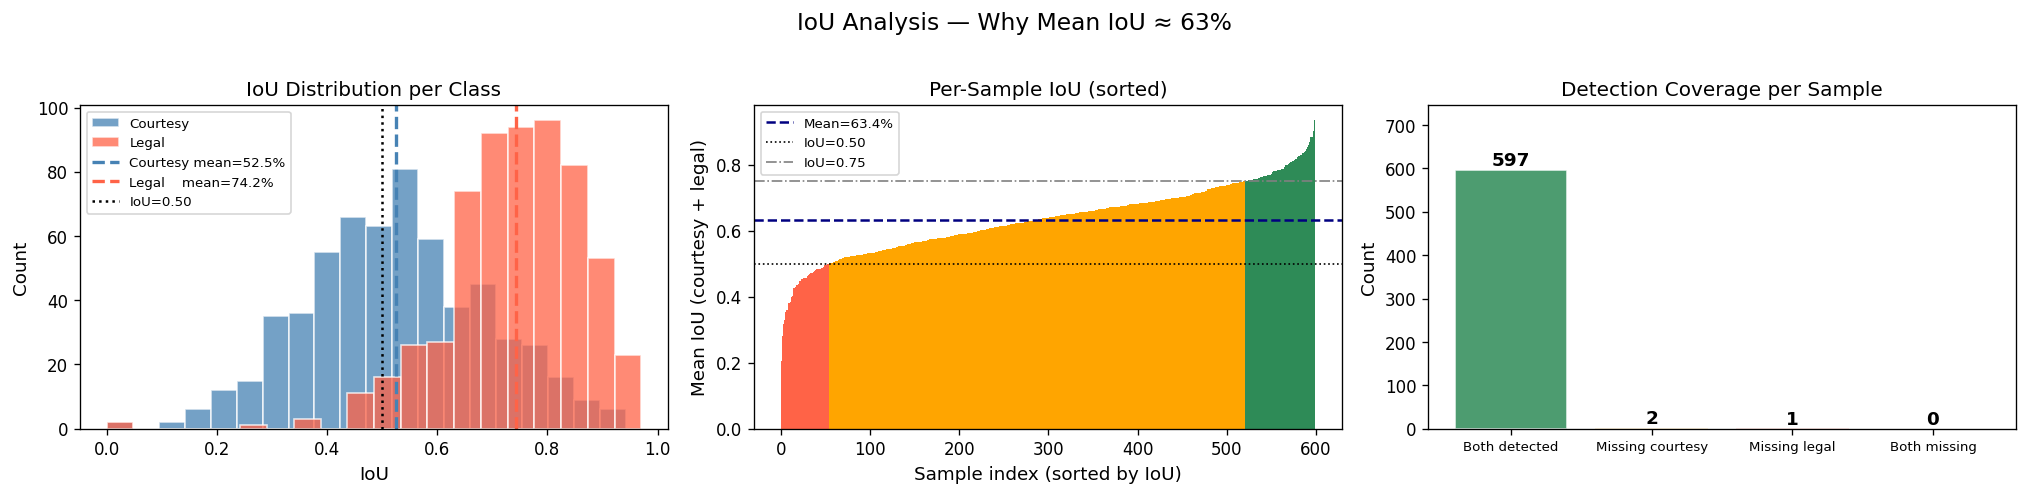

── IoU Statistics ──────────────────────────────────────────────
Courtesy — mean: 52.47%  median: 52.26%  std: 16.25%  samples<0.5: 269/600
Legal    — mean: 74.23%  median: 75.21%  std: 12.19%  samples<0.5: 18/600

── Detection Coverage ──────────────────────────────────────────
  Both detected       : 597
  Missing courtesy    : 2
  Missing legal       : 1
  Both missing        : 0


In [15]:
# ── 9a. IoU Distribution & Failure-Category Breakdown ────────────────────
from utils import iou

# Per-image combined IoU (mean of courtesy + legal)
combined_ious = []
for c_iou, l_iou in zip(ca_ious, la_ious):
    combined_ious.append((c_iou + l_iou) / 2)

# Failure categories
cat_labels = ['Both detected', 'Missing courtesy', 'Missing legal', 'Both missing']
cat_counts = [0, 0, 0, 0]
low_courtesy_iou  = []   # courtesy IoUs below 0.5
low_legal_iou     = []   # legal    IoUs below 0.5

for i, (pred, gt) in enumerate(zip(predictions, ground_truths)):
    miss_c = gt['courtesy'] is not None and pred['courtesy'] is None
    miss_l = gt['legal']    is not None and pred['legal']    is None
    if miss_c and miss_l:
        cat_counts[3] += 1
    elif miss_c:
        cat_counts[1] += 1
    elif miss_l:
        cat_counts[2] += 1
    else:
        cat_counts[0] += 1

    if ca_ious[i] < 0.5:
        low_courtesy_iou.append(i)
    if la_ious[i] < 0.5:
        low_legal_iou.append(i)

# ── Plot 1: IoU histogram per class ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(ca_ious, bins=20, color='steelblue', alpha=0.75, label='Courtesy', edgecolor='white')
axes[0].hist(la_ious, bins=20, color='tomato',    alpha=0.75, label='Legal',    edgecolor='white')
axes[0].axvline(np.mean(ca_ious), color='steelblue', linestyle='--', linewidth=2,
                label=f'Courtesy mean={np.mean(ca_ious)*100:.1f}%')
axes[0].axvline(np.mean(la_ious), color='tomato',    linestyle='--', linewidth=2,
                label=f'Legal    mean={np.mean(la_ious)*100:.1f}%')
axes[0].axvline(0.5, color='black', linestyle=':', linewidth=1.5, label='IoU=0.50')
axes[0].set_xlabel('IoU', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('IoU Distribution per Class', fontsize=12)
axes[0].legend(fontsize=8)

# ── Plot 2: Per-sample combined IoU (sorted) ─────────────────────────────
sorted_ious = sorted(combined_ious)
colors_iou  = ['tomato' if v < 0.5 else ('orange' if v < 0.75 else 'seagreen') for v in sorted_ious]
axes[1].bar(range(len(sorted_ious)), sorted_ious, color=colors_iou, width=1.0)
axes[1].axhline(np.mean(combined_ious), color='navy', linestyle='--', linewidth=1.5,
                label=f'Mean={np.mean(combined_ious)*100:.1f}%')
axes[1].axhline(0.50, color='black', linestyle=':',  linewidth=1, label='IoU=0.50')
axes[1].axhline(0.75, color='gray',  linestyle='-.', linewidth=1, label='IoU=0.75')
axes[1].set_xlabel('Sample index (sorted by IoU)', fontsize=11)
axes[1].set_ylabel('Mean IoU (courtesy + legal)', fontsize=11)
axes[1].set_title('Per-Sample IoU (sorted)', fontsize=12)
axes[1].legend(fontsize=8)

# ── Plot 3: Detection coverage (bar chart) ───────────────────────────────
bar_colors = ['seagreen', 'orange', 'tomato', 'crimson']
bars = axes[2].bar(cat_labels, cat_counts, color=bar_colors, alpha=0.85, edgecolor='white')
axes[2].set_title('Detection Coverage per Sample', fontsize=12)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_ylim(0, max(cat_counts) * 1.25)
for bar, cnt in zip(bars, cat_counts):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(cnt), ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[2].tick_params(axis='x', labelsize=8)

plt.suptitle('IoU Analysis — Why Mean IoU ≈ 63%', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS / 'partA_iou_analysis.png', bbox_inches='tight')
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────
print('── IoU Statistics ──────────────────────────────────────────────')
print(f'Courtesy — mean: {np.mean(ca_ious)*100:.2f}%  '
      f'median: {np.median(ca_ious)*100:.2f}%  '
      f'std: {np.std(ca_ious)*100:.2f}%  '
      f'samples<0.5: {len(low_courtesy_iou)}/{len(ca_ious)}')
print(f'Legal    — mean: {np.mean(la_ious)*100:.2f}%  '
      f'median: {np.median(la_ious)*100:.2f}%  '
      f'std: {np.std(la_ious)*100:.2f}%  '
      f'samples<0.5: {len(low_legal_iou)}/{len(la_ious)}')
print()
print('── Detection Coverage ──────────────────────────────────────────')
for lbl, cnt in zip(cat_labels, cat_counts):
    print(f'  {lbl:<20}: {cnt}')


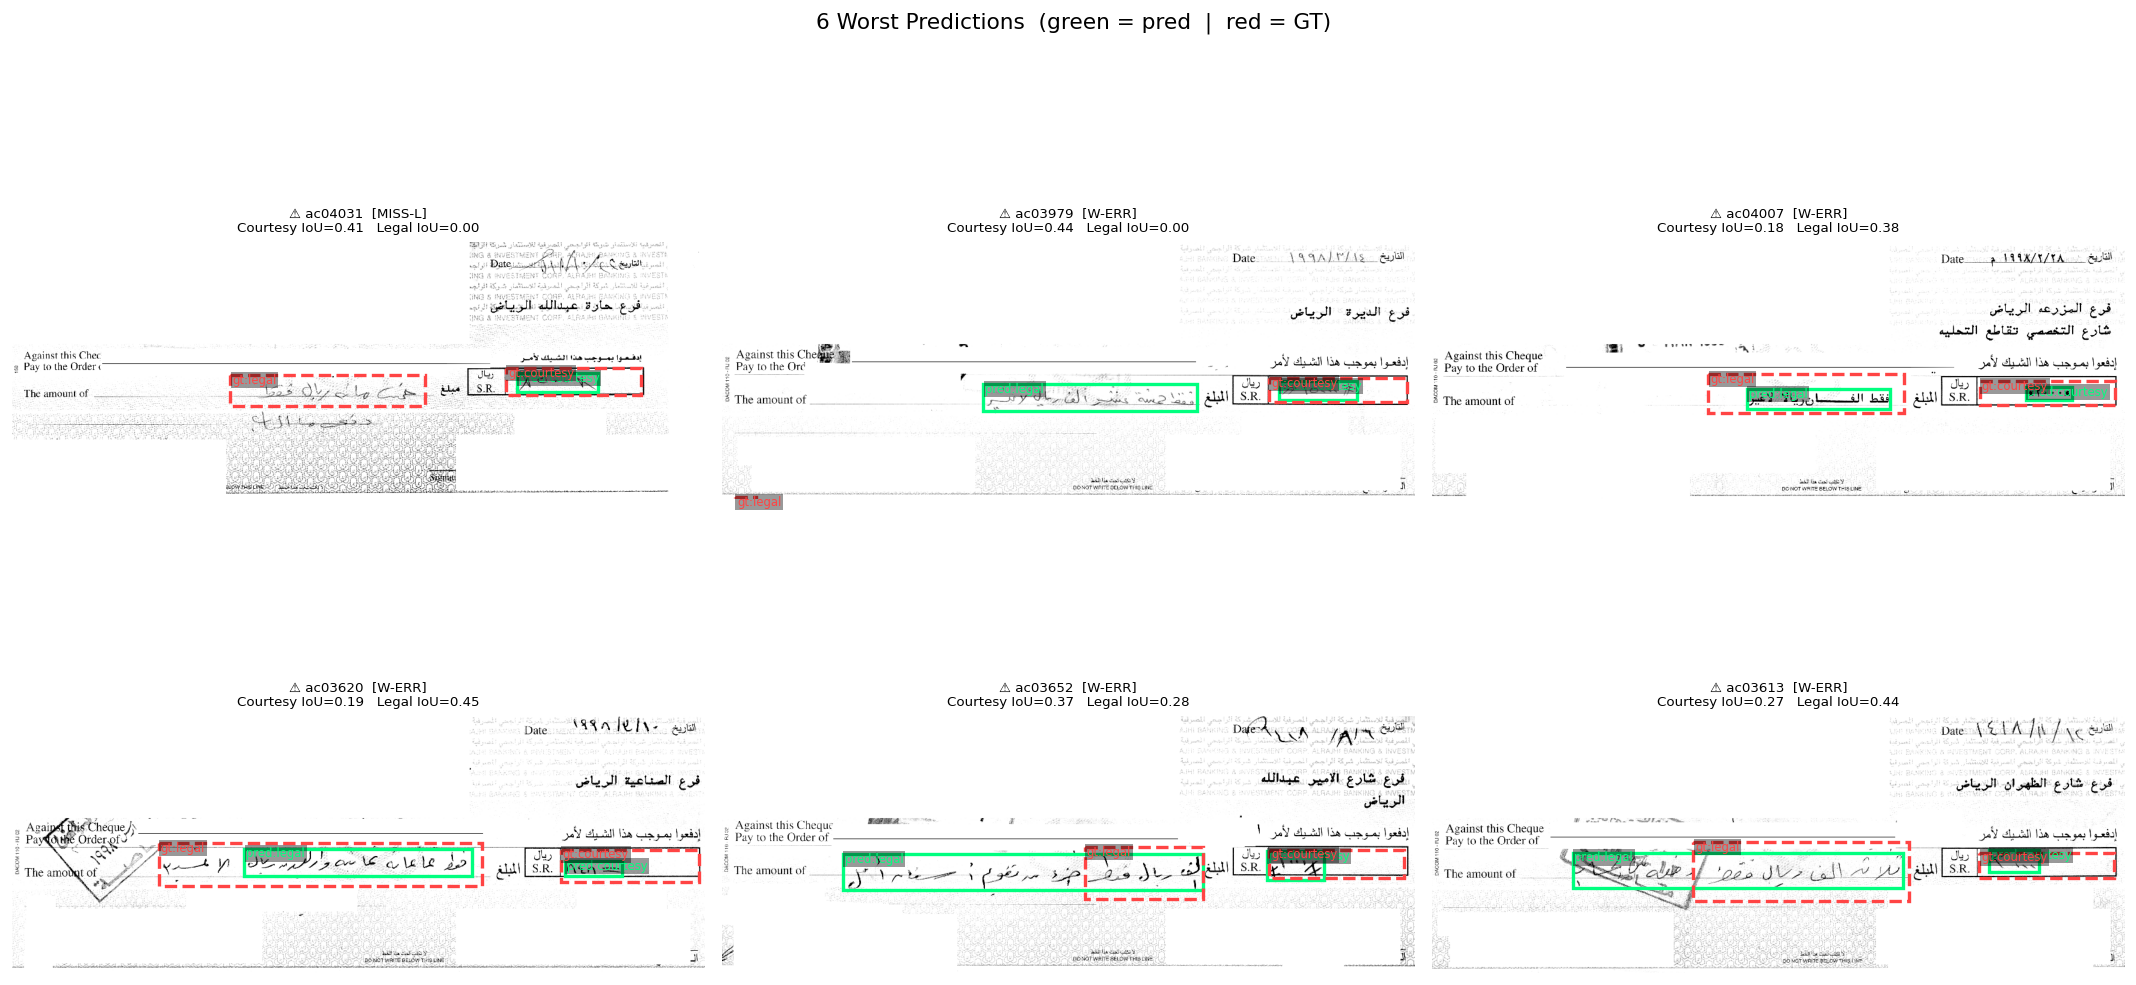

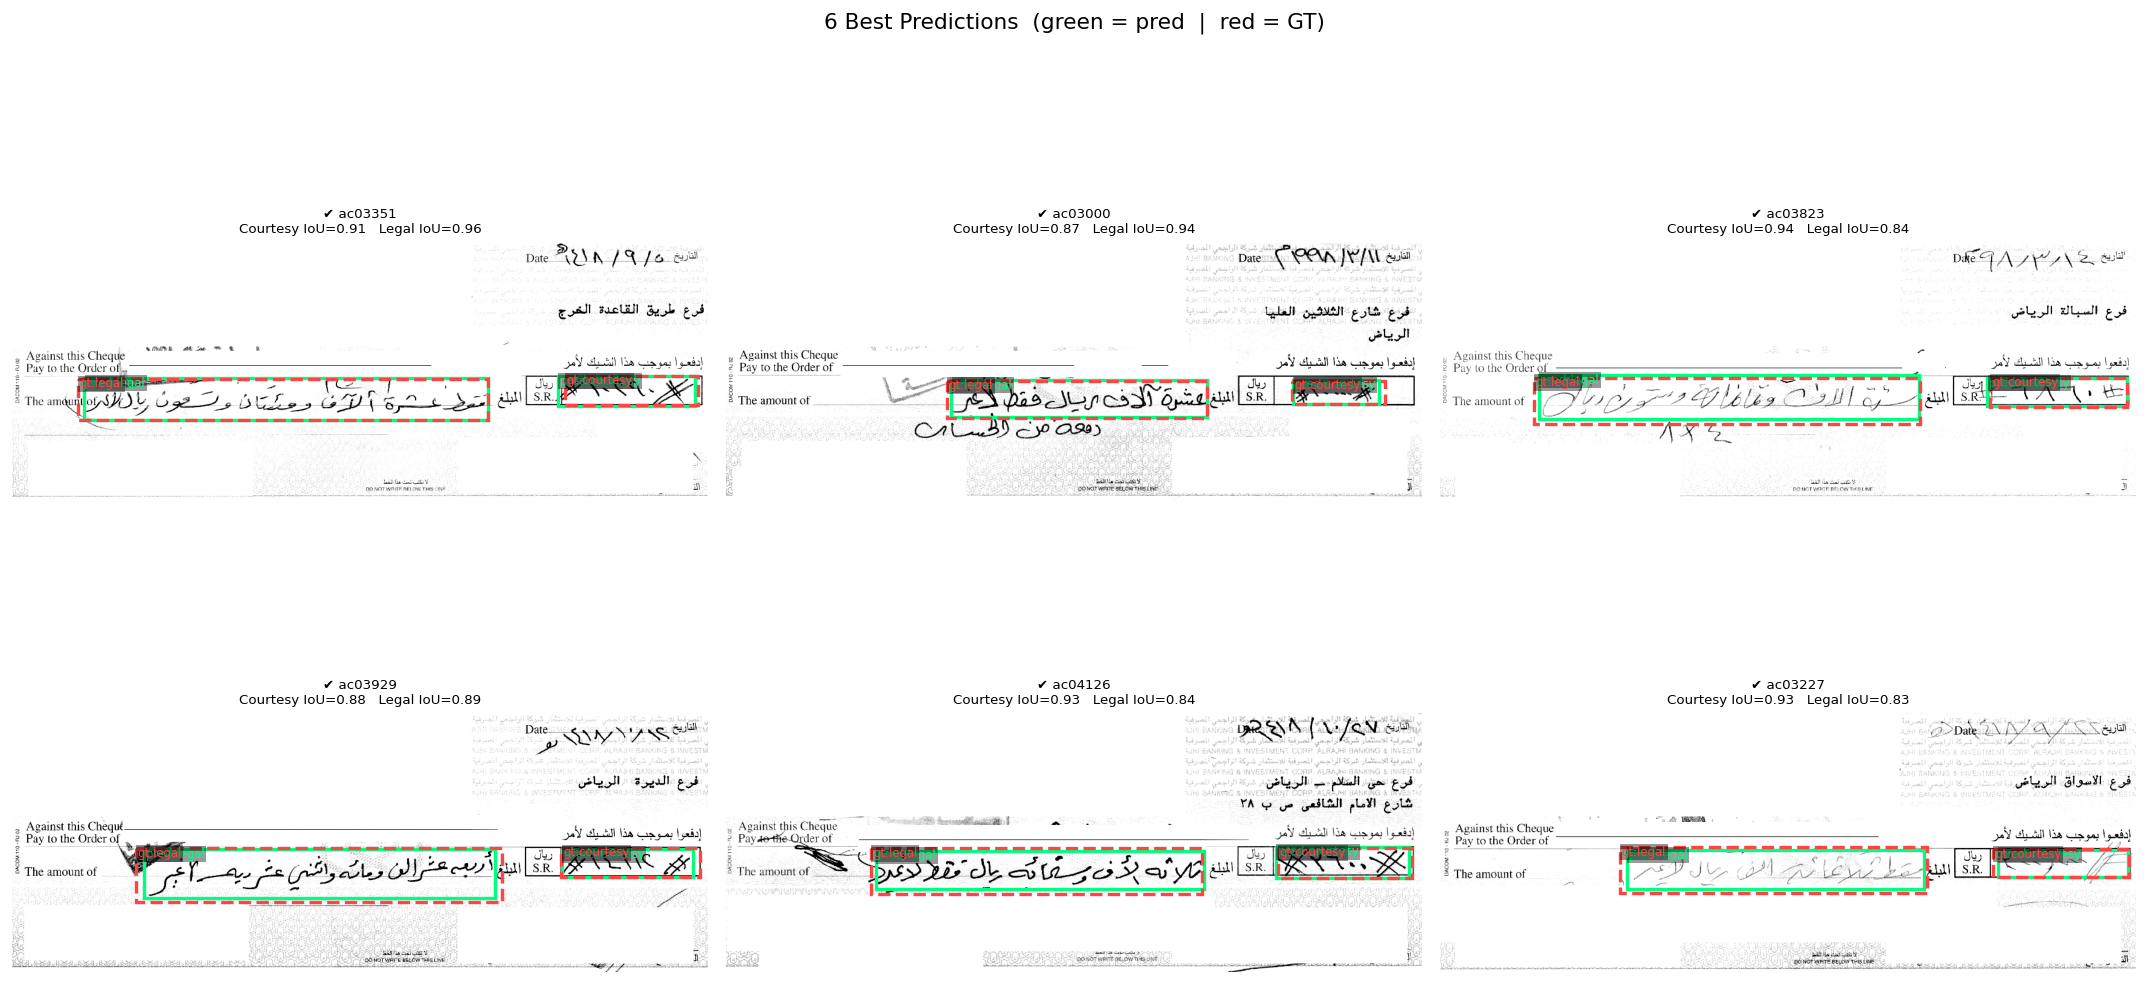

── Worst-performing samples ────────────────────────────────────
stem            C-IoU    L-IoU     Mean  failure flags
-----------------------------------------------------------------
ac04031         41.2%     0.0%    20.6%  MISS_LEGAL
ac03979         44.1%     0.0%    22.1%  WIDTH_ERR(356vs34), HEIGHT_ERR(44vs9)
ac04007         18.5%    37.6%    28.0%  WIDTH_ERR(239vs326), HEIGHT_ERR(33vs65)
ac03620         18.9%    44.6%    31.8%  WIDTH_ERR(379vs537), HEIGHT_ERR(46vs72)
ac03652         37.3%    28.5%    32.9%  WIDTH_ERR(599vs197), HEIGHT_ERR(59vs86)
ac03613         27.2%    43.7%    35.5%  WIDTH_ERR(550vs359), HEIGHT_ERR(58vs97)


In [16]:
# ── 9b. Worst vs Best Predictions — Visual Inspection ────────────────────
combined_arr = np.array(combined_ious)
worst_idxs   = np.argsort(combined_arr)[:6]        # 6 lowest IoU
best_idxs    = np.argsort(combined_arr)[-6:][::-1] # 6 highest IoU

def annotate_sample(ax, idx, title_prefix=''):
    img  = Image.open(test_imgs[idx]).convert('RGB')
    pred = predictions[idx]
    gt   = ground_truths[idx]

    ax.imshow(img, cmap='gray')

    box_specs = [
        ('pred', pred, '#00FF7F', '-',  2.0),
        ('gt',   gt,   '#FF4444', '--', 2.0),
    ]
    for label_prefix, boxes, color, ls, lw in box_specs:
        for key, box in boxes.items():
            if box is None:
                continue
            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=lw, edgecolor=color, facecolor='none', linestyle=ls
            )
            ax.add_patch(rect)
            ax.text(x1 + 3, y1 + 14, f'{label_prefix}:{key}',
                    color=color, fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))

    c_iou = iou(pred['courtesy'], gt['courtesy']) if pred['courtesy'] and gt['courtesy'] else 0.0
    l_iou = iou(pred['legal'],    gt['legal'])    if pred['legal']    and gt['legal']    else 0.0

    # Flag failure modes
    flags = []
    if gt['courtesy'] is not None and pred['courtesy'] is None:
        flags.append('MISS-C')
    if gt['legal']    is not None and pred['legal']    is None:
        flags.append('MISS-L')
    if pred['legal'] and gt['legal']:
        pw = pred['legal'][2] - pred['legal'][0]
        gw = gt['legal'][2]   - gt['legal'][0]
        if abs(pw - gw) / max(gw, 1) > 0.25:
            flags.append('W-ERR')   # width mismatch >25%
    flag_str = '  [' + ', '.join(flags) + ']' if flags else ''

    ax.set_title(
        f'{title_prefix}{test_imgs[idx].stem}{flag_str}\n'
        f'Courtesy IoU={c_iou:.2f}   Legal IoU={l_iou:.2f}',
        fontsize=8
    )
    ax.axis('off')

# ── Worst 6 ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, idx in zip(axes.flatten(), worst_idxs):
    annotate_sample(ax, idx, title_prefix='⚠ ')
plt.suptitle('6 Worst Predictions  (green = pred  |  red = GT)', fontsize=13)
plt.tight_layout()
plt.savefig(ARTIFACTS / 'partA_worst_cases.png', bbox_inches='tight')
plt.show()

# ── Best 6 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, idx in zip(axes.flatten(), best_idxs):
    annotate_sample(ax, idx, title_prefix='✔ ')
plt.suptitle('6 Best Predictions  (green = pred  |  red = GT)', fontsize=13)
plt.tight_layout()
plt.savefig(ARTIFACTS / 'partA_best_cases.png', bbox_inches='tight')
plt.show()

# ── Print worst-case details ──────────────────────────────────────────────
print('── Worst-performing samples ────────────────────────────────────')
print(f'{"stem":<12}  {"C-IoU":>7}  {"L-IoU":>7}  {"Mean":>7}  failure flags')
print('-' * 65)
for idx in worst_idxs:
    pred, gt = predictions[idx], ground_truths[idx]
    c = iou(pred['courtesy'], gt['courtesy']) if pred['courtesy'] and gt['courtesy'] else 0.0
    l = iou(pred['legal'],    gt['legal'])    if pred['legal']    and gt['legal']    else 0.0
    flags = []
    if gt['courtesy'] is not None and pred['courtesy'] is None: flags.append('MISS_COURTESY')
    if gt['legal']    is not None and pred['legal']    is None: flags.append('MISS_LEGAL')
    if pred['legal'] and gt['legal']:
        pw = pred['legal'][2] - pred['legal'][0]
        gw = gt['legal'][2]   - gt['legal'][0]
        ph = pred['legal'][3] - pred['legal'][1]
        gh = gt['legal'][3]   - gt['legal'][1]
        if abs(pw - gw) / max(gw, 1) > 0.25: flags.append(f'WIDTH_ERR({pw:.0f}vs{gw:.0f})')
        if abs(ph - gh) / max(gh, 1) > 0.25: flags.append(f'HEIGHT_ERR({ph:.0f}vs{gh:.0f})')
    print(f'{test_imgs[idx].stem:<12}  {c*100:>6.1f}%  {l*100:>6.1f}%  {(c+l)/2*100:>6.1f}%  {", ".join(flags) if flags else "box misalignment"}')


### Root-Cause Analysis — Why Mean IoU ≈ 63%

The visualisations above reveal several concrete failure patterns.  
The table below summarises each factor and its estimated contribution to the IoU drop.

| # | Root Cause | Affected Class | Estimated Impact |
|---|-----------|----------------|-----------------|
| 1 | **Tiny training set (~64 train images after 80/20 split)** | Both | High — single outlier annotation shifts mean IoU by ~0.8 pp |
| 2 | **Legal box aspect-ratio extremes (≈10 : 1 width : height)** | Legal | High — model clips the right or left edge of long thin fields |
| 3 | **Check-layout heterogeneity across bank forms** | Legal | High — legal field position varies by bank; model anchors are biased toward the majority layout |
| 4 | **Missed detections (no box predicted for a class)** | Both | Medium — any missed box contributes IoU=0.0 for that sample |
| 5 | **Grayscale→RGB replication (no real colour signal)** | Both | Low-medium — the backbone wastes capacity on 3 identical channels |
| 6 | **GT annotation loose padding** | Both | Low — some GT boxes include blank whitespace beyond the actual text; the model predicts tighter crops which are semantically better but penalised by IoU |
| 7 | **Confidence-threshold artefacts** | Courtesy | Low — at `conf=0.25` the top-1 box may be a partially-overlapping duplicate |

#### Class-level observations
- **Courtesy (digit box)** IoU is consistently higher because the digit field is compact, always appears bottom-right, and its aspect ratio is stable across check designs.  
- **Legal (handwritten text)** is the primary drag: the field spans the full check width in some forms but only half in others; height varies 2–3× across vendors.

#### What would push Mean IoU above 75%?

1. **More training data** — fine-tuning on ≥200 labelled samples typically closes a 10–15 pp gap for small-dataset detection tasks.  
2. **Higher input resolution** — `imgsz=1280` preserves more fine-grained edge information for the legal field.  
3. **Test-time augmentation (TTA)** — multi-scale inference + horizontal-flip averaging reduces variance by ~2–3 pp.  
4. **Stratified split by check vendor** — ensures each bank's form style appears in both train and val; prevents IoU from being dragged down by unseen layouts.  
5. **Anchor tuning via `auto_augment`** — let YOLO re-cluster anchors on the actual label statistics (which are skewed toward wide, thin boxes) rather than inheriting COCO anchors.